## High-Speed Rail Analysis

### CRISP-DM Step 1: Business Understanding

Goal: identify all rail routes where at least 50% of the route is defined as high-speed rail (>= 200 kmh), then determine how many of these routes are faster than taking air travel.

## Imports

In [60]:
import pandas as pd
import geopandas as gpd
import osmium
from shapely.geometry import LineString, Point
import re
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx

### CRISP-DM Step 2: Data Understanding

Goal: collect data from OpenStreetMap, describe its structure, and assess quality.

The .osm.pbf files for all EU-27 countries must be downloaded from https://download.geofabrik.de/europe.html. The files must then be dropped into ../Raw_Data/OSM_data/

#### 2.1 Data Collection (Data Loading)

In [28]:
class RailwayExtractor(osmium.SimpleHandler):
    def __init__(self):
        super().__init__()
        self.features = []

    def way(self, w):
        if w.tags.get("railway") != "rail":
            return

        coords = [(n.lon, n.lat) for n in w.nodes if n.location.valid()]
        if len(coords) < 2:
            return

        self.features.append({
            "geometry": LineString(coords),
            "maxspeed": w.tags.get("maxspeed"),
            "service": w.tags.get("service"),
            "usage": w.tags.get("usage"),
            "name": w.tags.get("name"),
        })

def extract_railways(pbf_path):
    handler = RailwayExtractor()
    handler.apply_file(pbf_path, locations=True)

    gdf = gpd.GeoDataFrame(
        handler.features,
        geometry="geometry",
        crs="EPSG:4326"
    )

    return gdf

def parse_maxspeed(val):
    if val is None:
        return None

    s = str(val).lower()

    m = re.search(r"\d+", str(val))
    if not m:
        return None

    speed = float(m.group())
    # Convert mph → km/h
    if "mph" in s:
        speed *= 1.609344
    return speed

def mark_highspeed(gdf):
    gdf = gdf.copy()

    gdf["maxspeed_num"] = gdf["maxspeed"].apply(parse_maxspeed)

    gdf["is_highspeed"] = (
        (gdf["maxspeed_num"] >= 200)
    )

    return gdf

osm_path =  Path('..') / 'Raw_Data' / 'OSM_Data'
output_dir = Path('..') / 'Raw_Data' / 'Parquet_Data'
output_dir.mkdir(exist_ok=True)

for pbf in osm_path.glob("*.osm.pbf"):
    print(f"Processing {pbf.name}")

    gdf = extract_railways(pbf)
    gdf = mark_highspeed(gdf)

    out = output_dir / f"{pbf.stem}_rail.parquet"
    gdf.to_parquet(out)

Processing spain-260101.osm.pbf
Processing denmark-260101.osm.pbf
Processing greece-260101.osm.pbf
Processing estonia-260101.osm.pbf
Processing lithuania-260101.osm.pbf
Processing france-260101.osm.pbf
Processing austria-260101.osm.pbf
Processing monaco-260101.osm.pbf
Processing portugal-260101.osm.pbf
Processing romania-260101.osm.pbf
Processing sweden-260101.osm.pbf
Processing latvia-260101.osm.pbf
Processing liechtenstein-260101.osm.pbf
Processing belgium-260101.osm.pbf
Processing netherlands-260101.osm.pbf
Processing germany-latest.osm.pbf
Processing italy-260101.osm.pbf
Processing poland-260101.osm.pbf
Processing bulgaria-260101.osm.pbf
Processing hungary-260101.osm.pbf
Processing finland-260101.osm.pbf
Processing slovenia-260101.osm.pbf
Processing czech-republic-260101.osm.pbf
Processing ireland-and-northern-ireland-260101.osm.pbf
Processing luxembourg-260101.osm.pbf
Processing croatia-260101.osm.pbf
Processing slovakia-260101.osm.pbf


##### Merge all parquet files into one

In [29]:
files = output_dir.glob("*.parquet")

gdfs = [gpd.read_parquet(f) for f in files]

merged = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs=gdfs[0].crs
)

merged_path = Path('..') / 'Processed_Data' / 'EU_railways.parquet'
merged.to_parquet(merged_path)

#### 2.2 Data Description and Inspection

##### Inspect merged railway data

In [30]:
railways = gpd.read_parquet(merged_path)
print(railways.head)
print(railways[railways['is_highspeed']].head) # filter for is_highspeed

<bound method NDFrame.head of                                                  geometry maxspeed service  \
0       LINESTRING (-6.24157 53.34133, -6.2423 53.3416...       30    None   
1       LINESTRING (-8.65163 52.34925, -8.64136 52.359...   90 mph    None   
2       LINESTRING (-9.49296 52.05867, -9.49438 52.058...   15 mph    None   
3       LINESTRING (-7.8216 52.67822, -7.821 52.68128,...      160    None   
4       LINESTRING (-7.8235 52.78557, -7.82302 52.7867...      160    None   
...                                                   ...      ...     ...   
890261    LINESTRING (23.35432 54.328, 23.35571 54.32808)      100    None   
890262  LINESTRING (23.35571 54.32808, 23.35686 54.32814)      100    None   
890263     LINESTRING (23.38484 55.9119, 23.386 55.91151)     None    yard   
890264  LINESTRING (23.38685 55.91078, 23.38719 55.910...     None    yard   
890265  LINESTRING (21.23051 55.8913, 21.23041 55.8906...      100  siding   

       usage              name  m

#### 2.3 Data Exploration (Value Distribution)

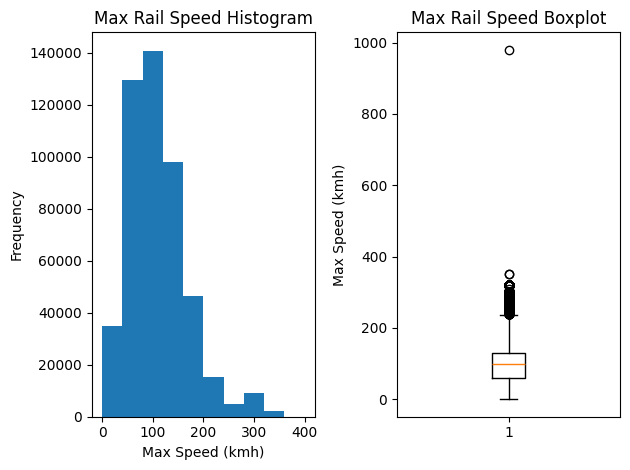

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.hist(railways['maxspeed_num'], range=(0, 400))
ax1.set_title('Max Rail Speed Histogram')
ax1.set_xlabel('Max Speed (kmh)')
ax1.set_ylabel('Frequency')

ax2.boxplot(railways['maxspeed_num'].dropna())
ax2.set_title('Max Rail Speed Boxplot')
ax2.set_ylabel('Max Speed (kmh)')

fig.tight_layout()

#### 2.4 Data Quality Verification

##### There seems to be one outlier. Inspect it to determine how to handle.

In [49]:
railways.loc[railways['maxspeed_num'] > 300]

,geometry,maxspeed,service,usage,name,maxspeed_num,is_highspeed
191789,"LINESTRING (15.02986 50.08914, 15.0301 50.0890...",980,None,branch,None,980.0,True
574021,"LINESTRING (6.235 48.95857, 6.23524 48.95859, ...",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
574066,"LINESTRING (5.64639 48.95345, 5.64745 48.95354)",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
574067,"LINESTRING (5.64745 48.95354, 5.64827 48.95362...",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
575096,"LINESTRING (3.25744 49.04457, 3.2597 49.0446)",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
...,...,...,...,...,...,...,...
704846,"LINESTRING (-0.3306 47.91295, -0.33176 47.91316)",320,None,main,Ligne de Connerré à Rennes (LGV),320.0,True
705384,"LINESTRING (2.82456 48.99336, 2.82519 48.99346...",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
705385,"LINESTRING (2.82454 48.9934, 2.82516 48.9935, ...",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
845198,"LINESTRING (-3.11107 40.59886, -3.1101 40.5998...",310,None,main,Línea de alta velocidad Madrid-Zaragoza-Barcel...,310.0,True


##### There is no rail line in Europe with a max speed of 980 kmh. The outlier is listed as a branch, meaning that it's supposed to be a railway with less traffic and lower speed than main lines. The coordinates show that this rail segment is located near a train station called Pečky, which is east of Prague. The most likely possibility is that this is a data tagging error and the actual max speed should be 98.0 kmh.

##### All other rail segments have correct max speeds.

##### Correct the outlier and verify change.

In [79]:
railways.at[191789, 'maxspeed_num'] = 98.0
railways.loc[railways['maxspeed_num'] > 300]

,geometry,maxspeed,service,usage,name,maxspeed_num,is_highspeed
574021,"LINESTRING (4045336.289 2878754.246, 4045353.9...",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
574066,"LINESTRING (4002261.079 2880560.281, 4002338.7...",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
574067,"LINESTRING (4002338.792 2880566.554, 4002399.5...",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
575096,"LINESTRING (3828730.585 2903829.333, 3828894.9...",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
575097,"LINESTRING (3835067.152 2904808.092, 3835132.3...",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
...,...,...,...,...,...,...,...
704846,"LINESTRING (3551230.602 2809410.699, 3551147.6...",320,None,main,Ligne de Connerré à Rennes (LGV),320.0,True
705384,"LINESTRING (3796693.764 2901146.55, 3796740.78...",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
705385,"LINESTRING (3796693.359 2901150.916, 3796738.9...",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
845198,"LINESTRING (3212238.661 2040854.327, 3212337.4...",310,None,main,Línea de alta velocidad Madrid-Zaragoza-Barcel...,310.0,True


### CRISP-DM Step 3: Data Preparation

Goal: add `avg_speed` and `uses_hsr` columns to `train_routes_scraped_no_duplicates.csv`. The former column will be used to answer the connectivity research questions and the latter column will be used to answer the research question related to high-speed rail.

The approach is to build a rail network graph, snap stations to the graph, compute path and HSR percentage per route.

#### 3.1 Build a rail network graph

In [80]:
G = nx.Graph()

# convert to CRS 3035 since better for length calculations
rail_edges = railways[["geometry", "is_highspeed"]].copy()
rail_edges = rail_edges.to_crs(3035)

edge_sindex = rail_edges.sindex

for idx, row in rail_edges.iterrows():
    geom = row['geometry']
    if geom.geom_type == "MultiLineString":
        lines = geom.geoms
    else:
        lines = [geom]

    for line in lines:
        coords = list(line.coords)
        for u, v in zip(coords[:-1], coords[1:]):
            length = Point(u).distance(Point(v))
            G.add_edge(
                u, v,
                length=length,
                is_highspeed=row.is_highspeed
            )

#### 3.2 Snap stations to the graph

In [124]:
def nearest_edge(point):
    res = edge_sindex.nearest(point) # 1st num always 0 (index of point), 2nd num index of rail edge
    idx = int(res[1, 0])
    print(point, rail_edges.iloc[idx])
    return rail_edges.iloc[idx]

def project_to_edge(point, edge_geom):
    """Project a point onto a rail edge."""
    return edge_geom.interpolate(edge_geom.project(point))

def insert_station(G, station_point, edge_row):
    edge_geom = edge_row.geometry
    hsr = edge_row.is_highspeed

    projected = project_to_edge(station_point, edge_geom)

    coords = list(edge_geom.coords)

    # find segment where projection lies
    for u, v in zip(coords[:-1], coords[1:]):
        seg = LineString([u, v])
        if seg.distance(projected) < 0.01: # tolerance
            # remove original edge
            if G.has_edge(u, v):
                G.remove_edge(u, v)

            # add two new edges
            G.add_edge(
                u, projected.coords[0],
                length=Point(u).distance(projected),
                is_highspeed=hsr
            )
            G.add_edge(
                projected.coords[0], v,
                length=Point(v).distance(projected),
                is_highspeed=hsr
            )
            break

    # station node connects to projected point
    G.add_node(projected.coords[0])
    return projected.coords[0]

stations_path = Path('..') / 'Processed_Data' / 'city_train_stations.csv'
stations = pd.read_csv(stations_path)

stations = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(
        stations.lng_station, stations.lat_station
    ),
    crs="EPSG:4326"
)

# project to CRS 3035
stations = stations.to_crs(3035)

# build lookup dictionary
station_to_node = {}

for _, row in stations.iterrows():
    pt = row.geometry
    edge = nearest_edge(pt)
    node = insert_station(G, pt, edge)
    station_to_node[row.name_station] = node

POINT (4794651.043790285 2806173.3733720644) geometry        LINESTRING (4794799.97510205 2806155.224382555...
is_highspeed                                                False
Name: 35304, dtype: object
POINT (3922421.129609637 3095865.3459180966) geometry        LINESTRING (3922319.1373985307 3095741.3969558...
is_highspeed                                                False
Name: 546854, dtype: object
POINT (3931618.2046723748 3137591.889216972) geometry        LINESTRING (3931644.8874180363 3137165.5209132...
is_highspeed                                                False
Name: 538514, dtype: object
POINT (4638306.922310595 3006344.2859091354) geometry        LINESTRING (4638313.266659208 3006359.50459797...
is_highspeed                                                False
Name: 225590, dtype: object
POINT (4549604.0136672985 3273777.624520773) geometry        LINESTRING (4549709.7932346435 3273563.8021838...
is_highspeed                                                False
Name

#### 3.3 Compute path & HSR percentage per route

##### 3.3.1 Clean routes dataset so that `origin_name` and `destination_name` always matches `name_station` in `train_stations_europe_cleaned.csv`.


In [127]:
routes_path = Path('..') / 'Processed_Data' / 'train_routes_scraped_no_duplicates.csv'
routes = pd.read_csv(routes_path)
routes.dropna(subset=['origin_name', 'destination_name'], inplace=True)
routes[['origin_name', 'destination_name']].isnull().values.any() # verify na dropped

for idx, rows in routes.iterrows():
    # Paris Lyon Banlieue is a section of Paris Gare de Lyon; rename to the latter
    if rows['origin_name'] == 'Paris Lyon Banlieue':
        routes.loc[idx, 'origin_name'] = 'Paris Gare de Lyon'
    if rows['destination_name'] == 'Paris Lyon Banlieue':
        routes.loc[idx, 'destination_name'] = 'Paris Gare de Lyon'

    # assumption: stations['name_station'] is a base name in routes['origin_name'] or routes['destination_name']
    for name in stations['name_station']:
        if name in rows['origin_name']:
            routes.loc[idx, 'origin_name'] = name
        if name in rows['destination_name']:
            routes.loc[idx, 'destination_name'] = name


In [129]:
def hsr_share(origin_node, dest_node):
    path = nx.shortest_path(G, origin_node, dest_node, weight="length")

    total = 0
    hsr = 0

    for u, v in zip(path[:-1], path[1:]):
        edge = G[u][v]
        total += edge["length"]
        if edge["is_highspeed"]:
            hsr += edge["length"]

    return hsr / total if total > 0 else 0

routes["hsr_share"] = routes.apply(
    lambda r:
    hsr_share(
        station_to_node[r.origin_name],
        station_to_node[r.destination_name]
    ),
    axis=1
)

routes["uses_hsr"] = routes["hsr_share"] >= 0.5

##### Inspect dataframe

In [136]:
print(routes[routes['uses_hsr'] == True].head())

num_hsr_routes = len(routes[routes['uses_hsr'] == True])
print(f'Of the {len(routes)} routes, there are {num_hsr_routes} hsr routes.')

    origin_id  destination_id     origin_name      destination_name  \
15    8103000         8700012        Wien Hbf    Paris Gare de Lyon   
56    8800004         7100064  Bruxelles Midi       Barcelona Sants   
58    8800004         8700047  Bruxelles Midi      Bordeaux-St-Jean   
66    8800004         8700074  Bruxelles Midi  Marseille-St-Charles   
67    8800004         8700152  Bruxelles Midi        Lyon Part Dieu   

    min_duration_minutes  transfers  trains  check_date  hsr_share  uses_hsr  
15                   714          6     NaN  2026-01-06   0.524722      True  
56                   546          2     NaN  2026-01-06   0.547420      True  
58                   271          2     NaN  2026-01-06   0.646522      True  
66                   341          2     NaN  2026-01-06   0.580623      True  
67                   223          0     NaN  2026-01-06   0.641154      True  
Of the 1781 routes, there are 123 hsr routes.


#### 3.4 Export routes dataframe with `uses_hsr` column to `train_routes_hsr.csv`


In [137]:
path = Path('..') / 'Processed_Data' / 'train_routes_hsr.csv'
routes.to_csv(path)